# Data Understanding & Preprocessing for Multiclass Disease Classification



### Objective

This notebook establishes a robust and reproducible data preprocessing pipeline for a multiclass disease classification problem using a synthetic clinical dataset.

The primary goals are to:

* Understand dataset structure, feature composition, and target distribution
* Validate data quality, including missing values, duplicates, and data consistency
* Analyze class imbalance and its potential impact on model performance
* Examine symptom prevalence and feature characteristics
* Identify and address rare classes to ensure reliable model training
* Prepare the dataset for downstream machine learning tasks through encoding and stratified splitting

This work forms the foundation for building accurate, interpretable, and scalable machine learning models.

### Scope

This notebook focuses strictly on **data understanding and preprocessing**.
Model development, evaluation, and optimization are addressed in subsequent stages.

### Outputs

The following artifacts are generated:

* Cleaned and validated dataset
* Encoded target labels with mapping
* Stratified train, validation, and test splits
* Reproducible preprocessing pipeline

These outputs ensure consistency, traceability, and readiness for modeling and deployment.


In [21]:
# Core libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Preprocessing utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Plot settings
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

In [22]:

# Reproducibility & Configuration


import numpy as np
import random

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"Using RANDOM_SEED = {RANDOM_SEED}")

Using RANDOM_SEED = 42


### Data Loading

The dataset is loaded from the project’s raw data directory without applying any transformations. Maintaining an untouched version of the raw data ensures full traceability and reproducibility of all preprocessing steps.


The dataset used in this study is sourced from Kaggle:

**Community Healthcare Multi-Symptoms Disease Dataset**
https://www.kaggle.com/datasets/arjunnairedu/community-healthcare-multisymptomsdisease-dataset

The dataset represents a simulated clinical environment, where each record corresponds to a patient case with binary symptom indicators and an associated disease label.



In [23]:
# Define data path
data_path = "../data/raw/Community Healthcare MultiSymptomsDisease Diagnostic Dataset.csv"


# Load dataset
df = pd.read_csv(data_path)

# Basic validation
assert df is not None and not df.empty, "Dataset failed to load or is empty."
assert "disease" in df.columns, "Target column 'disease' is missing."

# Dataset overview
print(f"Dataset loaded successfully from: {data_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully from: ../data/raw/Community Healthcare MultiSymptomsDisease Diagnostic Dataset.csv
Shape: 100,000 rows × 175 columns


In [24]:
# Basic structure
print(f"Dataset Shape: {df.shape}")

# Preview sample records
display(df.head())

# Column overview
print("\nColumn Summary:")
print(f"Total Columns: {len(df.columns)}")
print(f"Target Column: 'disease'")
print(f"Feature Columns: {len(df.columns) - 1}")

Dataset Shape: (100000, 175)


,disease,symptom_cough,symptom_dry_cough,symptom_productive_cough,symptom_shortness_of_breath,symptom_wheezing,symptom_chest_tightness,symptom_sore_throat,symptom_runny_nose,symptom_nasal_congestion,...,rare_symptom_tall_stature_rare,rare_symptom_hyperextensible_skin_rare,rare_symptom_joint_hypermobility_rare,rare_symptom_macroglossia_rare,rare_symptom_hearing_loss_early_onset_rare,rare_symptom_developmental_delay_rare,rare_symptom_proximal_muscle_weakness_rare,rare_symptom_bulbar_symptoms_rare,rare_symptom_respiratory_failure_rare,rare_symptom_renal_cysts_rare
0,Hyperthyroidism,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Coronary_Artery_Disease,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Irritable_Bowel_Syndrome,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Irritable_Bowel_Syndrome,0,0,0,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,Obesity,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0



Column Summary:
Total Columns: 175
Target Column: 'disease'
Feature Columns: 174


### Initial Data Inspection

The dataset contains **100,000 records and 175 variables**, representing individual patient cases.

* **174 columns** correspond to symptom indicators
* **1 column (`disease`)** represents the target label
* Features are encoded as **binary variables (0/1)**

The dataset is well-structured and suitable for multiclass classification tasks.


In [25]:
# Define target and feature columns
target_column = "disease"
feature_columns = [col for col in df.columns if col != target_column]

# Summary
print(f"Target Column: {target_column}")
print(f"Number of Classes: {df[target_column].nunique()}")
print(f"Number of Features: {len(feature_columns)}")

# Preview feature names
print("\nSample Features:")
display(feature_columns[:15])

Target Column: disease
Number of Classes: 46
Number of Features: 174

Sample Features:


['symptom_cough',
 'symptom_dry_cough',
 'symptom_productive_cough',
 'symptom_shortness_of_breath',
 'symptom_wheezing',
 'symptom_chest_tightness',
 'symptom_sore_throat',
 'symptom_runny_nose',
 'symptom_nasal_congestion',
 'symptom_sinus_pain',
 'symptom_loss_of_smell',
 'symptom_loss_of_taste',
 'symptom_pleuritic_chest_pain',
 'symptom_hemoptysis',
 'symptom_exercise_dyspnea']

### Target and Feature Definition

* **Target variable:** `disease` (46 classes)
* **Features:** 174 binary symptom indicators

Each feature represents the presence (1) or absence (0) of a symptom.

This setup defines a **multiclass classification problem**, where diseases are predicted based on symptom patterns.


In [26]:
# Data types overview
df.info()

# Summary
print("\nData Types:")
display(df.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 175 entries, disease to rare_symptom_renal_cysts_rare
dtypes: int64(174), object(1)
memory usage: 133.5+ MB

Data Types:


int64     174
object      1
Name: count, dtype: int64

### Data Types

The dataset consists of:

* **174 integer features** representing binary symptom indicators
* **1 categorical target variable (`disease`)**

All feature columns are correctly stored as numeric types, and the target variable is appropriately represented as a categorical label.

This structure is consistent with a supervised classification problem and requires no type correction.


In [27]:
# Check missing values
missing_values = df.isnull().sum().sum()

print(f"Total Missing Values: {missing_values}")

Total Missing Values: 0


### Missing Values

No missing values were detected in the dataset.

This indicates complete feature and target coverage across all 100,000 records and removes the need for imputation at this stage.

In [28]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Duplicate Records

No duplicate rows were identified in the dataset.

This ensures that each observation is unique and reduces the risk of data leakage during model training and evaluation.

Number of Classes: 46
Largest Class: 21295
Smallest Class: 1
Imbalance Ratio: 21295


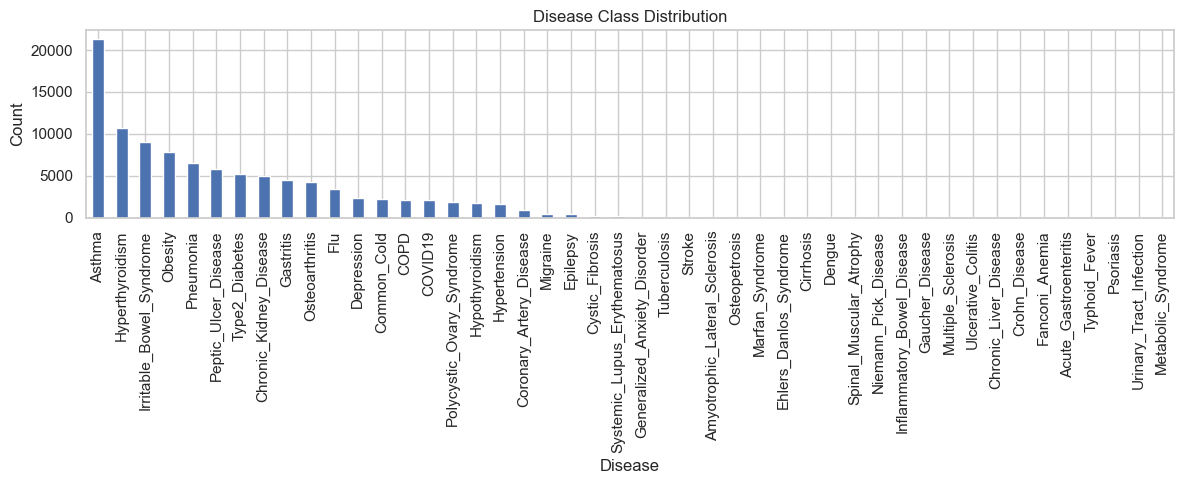

In [29]:
# Class distribution
class_counts = df["disease"].value_counts()

# Basic stats
print(f"Number of Classes: {class_counts.shape[0]}")
print(f"Largest Class: {class_counts.max()}")
print(f"Smallest Class: {class_counts.min()}")
print(f"Imbalance Ratio: {class_counts.max() / class_counts.min():.0f}")

# Plot
plt.figure(figsize=(12, 5))
class_counts.plot(kind="bar")
plt.title("Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../results/graphs/class_distribution.png", dpi=300)
plt.show()

### Target Distribution and Class Imbalance

The dataset contains 46 disease classes with a highly imbalanced distribution.

The largest class contains over 21,000 observations, while some classes contain fewer than 10 cases
The imbalance ratio exceeds 20,000:1, indicating a strong long-tail distribution

This imbalance can bias models toward majority classes and reduce performance on rare diseases.

To address this, evaluation should rely on metrics such as macro-averaged F1-score rather than accuracy alone.

### Dataset Characteristics and Limitations

The dataset used in this study is a simulated clinical dataset obtained from a publicly available source on Kaggle. Access to real-world medical data is often highly restricted due to privacy concerns, ethical considerations, and regulatory constraints (e.g., patient confidentiality and data protection laws). As a result, simulated datasets are commonly used in research to enable experimentation while preserving privacy.

This dataset is designed to reflect realistic symptom–disease relationships and provides a structured representation of clinical cases. However, it does not fully capture the complexity of real-world healthcare data.

In particular, the dataset contains no missing values and exhibits consistent feature formatting. While this simplifies preprocessing and allows controlled experimentation, it may limit the generalizability of the results to real clinical environments, where data is often incomplete, noisy, and heterogeneous.

Therefore, the findings of this study should be interpreted within the context of a simulated dataset. Future work should focus on validating the proposed methods using real-world clinical data to assess robustness and practical applicability.



The target variable shows a strong long-tail distribution. A few disease classes contain many observations, while several classes have very limited support.

This imbalance is important because it can bias models toward majority classes and make class-wise evaluation less reliable. It also creates challenges for stratified data splitting when very small classes are present.

In [30]:
# Summary statistics
display(df[feature_columns].describe())

# Binary validation
non_binary_columns = [
    col for col in feature_columns
    if not set(df[col].dropna().unique()).issubset({0, 1})
]

print(f"Non-binary columns: {len(non_binary_columns)}")

,symptom_cough,symptom_dry_cough,symptom_productive_cough,symptom_shortness_of_breath,symptom_wheezing,symptom_chest_tightness,symptom_sore_throat,symptom_runny_nose,symptom_nasal_congestion,symptom_sinus_pain,...,rare_symptom_tall_stature_rare,rare_symptom_hyperextensible_skin_rare,rare_symptom_joint_hypermobility_rare,rare_symptom_macroglossia_rare,rare_symptom_hearing_loss_early_onset_rare,rare_symptom_developmental_delay_rare,rare_symptom_proximal_muscle_weakness_rare,rare_symptom_bulbar_symptoms_rare,rare_symptom_respiratory_failure_rare,rare_symptom_renal_cysts_rare
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.254750,0.253860,0.254120,0.25610,0.254770,0.256040,0.254740,0.255330,0.253420,0.254640,...,0.001460,0.002520,0.001110,0.002140,0.001870,0.003060,0.000850,0.001840,0.002720,0.001300
std,0.435723,0.435221,0.435368,0.43648,0.435734,0.436446,0.435717,0.436049,0.434971,0.435661,...,0.038182,0.050137,0.033298,0.046211,0.043203,0.055233,0.029143,0.042856,0.052083,0.036032
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Non-binary columns: 0


### Feature Summary and Validation

Summary statistics confirm that all feature variables are binary, with values restricted to 0 and 1.

* Feature means represent symptom prevalence across the dataset
* Minimum and maximum values confirm correct binary encoding

All features are consistent with their intended representation as symptom indicators, requiring no further correction.


---

In [31]:
# Symptom frequency
symptom_counts = df[feature_columns].sum().sort_values(ascending=False)

# Top symptoms
print("Top 10 Most Frequent Symptoms:")
display(symptom_counts.head(10))

# Least frequent symptoms
print("\nTop 10 Least Frequent Symptoms:")
display(symptom_counts.tail(10))

Top 10 Most Frequent Symptoms:


symptom_loss_of_smell           25662
symptom_shortness_of_breath     25610
symptom_chest_tightness         25604
symptom_pleuritic_chest_pain    25583
symptom_exercise_dyspnea        25573
symptom_runny_nose              25533
symptom_facial_puffiness        25492
symptom_loss_of_taste           25484
symptom_wheezing                25477
symptom_cough                   25475
dtype: int64


Top 10 Least Frequent Symptoms:


rare_symptom_renal_cysts_rare                 130
rare_symptom_digital_clubbing                 129
rare_symptom_bone_marrow_failure_rare         128
rare_symptom_angiokeratomas_rare              127
rare_symptom_joint_hypermobility_rare         111
rare_symptom_hepatosplenomegaly_rare           91
rare_symptom_optic_neuritis_rare               85
rare_symptom_proximal_muscle_weakness_rare     85
rare_symptom_foot_drop_rare                    65
rare_symptom_bronchiectasis_rare               57
dtype: int64

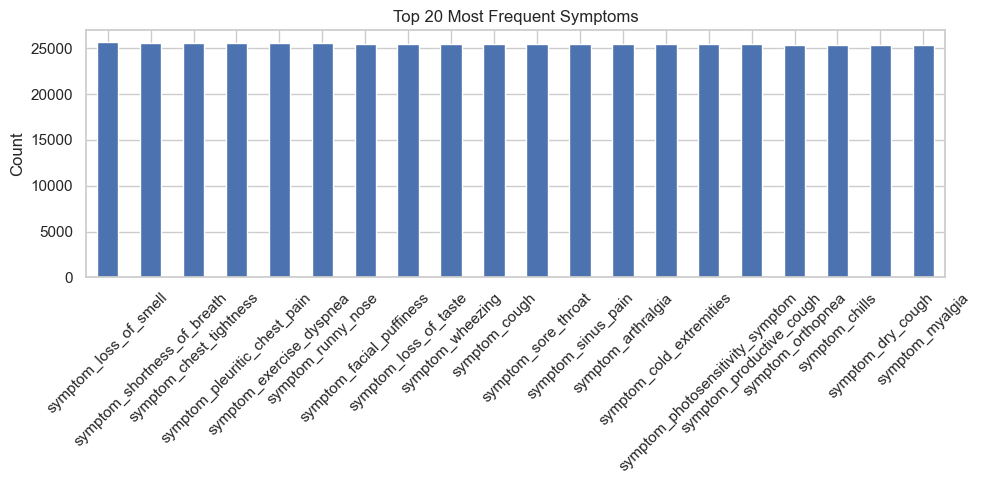

In [32]:
# Plot top 20 symptoms
plt.figure(figsize=(10, 5))
symptom_counts.head(20).plot(kind="bar")
plt.title("Top 20 Most Frequent Symptoms")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/graphs/top_symptoms.png", dpi=300)
plt.show()

### Symptom Frequency Analysis

Symptom prevalence is relatively uniform across the dataset, with most symptoms appearing in approximately **25% of cases (~25,000 occurrences)**.

* High-frequency symptoms such as **loss of smell, shortness of breath, chest tightness, and dyspnea-related indicators** dominate the dataset
* The narrow range of frequencies suggests a **controlled synthetic distribution**, rather than natural real-world variability
* No symptom is extremely rare or overwhelmingly dominant

This uniformity implies that:

* Individual symptoms may have **limited discriminative power in isolation**
* Predictive performance will likely depend on **combinations of symptoms rather than single features**

Overall, the dataset emphasizes **pattern-based diagnosis**, aligning with the nature of clinical decision-making.


In [33]:
# Calculate percentage distribution of diseases
class_percent = (class_counts / len(df)) * 100


class_percent_df = class_percent.reset_index()
class_percent_df.columns = ["Disease", "Percentage"]

display(class_percent_df.head(20))

,Disease,Percentage
0,Asthma,21.295
1,Hyperthyroidism,10.747
2,Irritable_Bowel_Syndrome,9.023
3,Obesity,7.853
4,Pneumonia,6.493
5,Peptic_Ulcer_Disease,5.834
6,Type2_Diabetes,5.239
7,Chronic_Kidney_Disease,4.993
8,Gastritis,4.431
9,Osteoarthritis,4.264


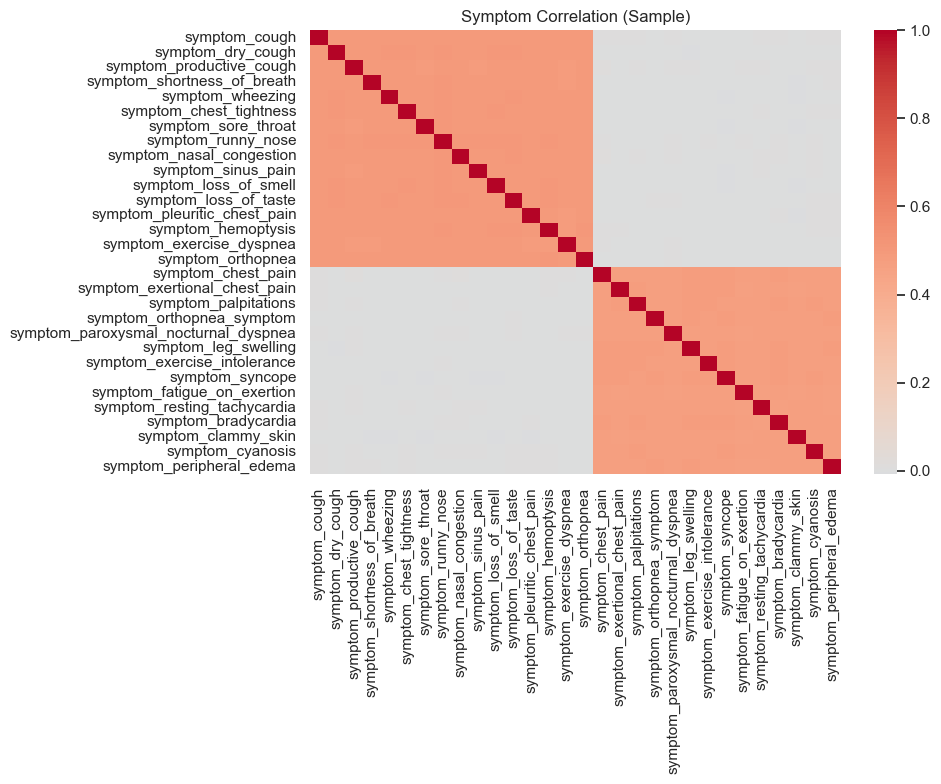

In [34]:
# Correlation matrix (sample for readability)
corr_matrix = df[feature_columns].corr()

# Plot subset (first 30 features)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.iloc[:30, :30], cmap="coolwarm", center=0)
plt.title("Symptom Correlation (Sample)")
plt.tight_layout()

plt.savefig("../results/graphs/symptom_correlation.png", dpi=300)
plt.show()

## Symptom Relationships

Correlation analysis reveals structured relationships between symptoms, forming distinct clusters.

* A **respiratory cluster** is evident among symptoms such as:

  * cough, dry cough, productive cough
  * shortness of breath, wheezing, chest tightness

* A second cluster is observed among **cardiovascular-related symptoms**, including:

  * chest pain, palpitations, edema-related features

* Correlation values are generally **moderate (~0.15–0.20)**, indicating:

  * Symptoms tend to co-occur
  * However, features are not strongly redundant

The block-like structure in the correlation heatmap confirms that symptoms are **grouped into clinically meaningful patterns**, rather than being randomly distributed.

This structure is beneficial for modeling, as it reflects realistic relationships while maintaining sufficient feature diversity.


In [35]:
# Co-occurrence matrix
co_occurrence = np.dot(df[feature_columns].T, df[feature_columns])

co_occurrence_df = pd.DataFrame(
    co_occurrence,
    index=feature_columns,
    columns=feature_columns
)

# Display sample
co_occurrence_df.iloc[:10, :10]

,symptom_cough,symptom_dry_cough,symptom_productive_cough,symptom_shortness_of_breath,symptom_wheezing,symptom_chest_tightness,symptom_sore_throat,symptom_runny_nose,symptom_nasal_congestion,symptom_sinus_pain
symptom_cough,25475,15896,15848,15904,15904,15993,15859,15981,15891,15846
symptom_dry_cough,15896,25386,15868,15902,15974,16035,15856,16004,15883,15873
symptom_productive_cough,15848,15868,25412,15861,15891,15941,15765,15930,15795,15797
symptom_shortness_of_breath,15904,15902,15861,25610,15959,15964,15969,16099,15928,15902
symptom_wheezing,15904,15974,15891,15959,25477,16006,15888,16020,15880,15845
symptom_chest_tightness,15993,16035,15941,15964,16006,25604,15980,16145,15933,15924
symptom_sore_throat,15859,15856,15765,15969,15888,15980,25474,16033,15840,15888
symptom_runny_nose,15981,16004,15930,16099,16020,16145,16033,25533,16008,16001
symptom_nasal_congestion,15891,15883,15795,15928,15880,15933,15840,16008,25342,15878
symptom_sinus_pain,15846,15873,15797,15902,15845,15924,15888,16001,15878,25464


### Symptom Co-occurrence

Co-occurrence analysis provides further insight into how symptoms appear together across patient cases.

* Pairwise co-occurrence counts are consistently in the range of **~15,000–16,000**, while individual symptom totals are ~25,000
* This indicates that when a symptom is present, it frequently appears alongside multiple related symptoms

Key observations:

* Respiratory symptoms (e.g., cough variants, shortness of breath) frequently co-occur, reinforcing the presence of a **respiratory symptom cluster**
* High co-occurrence between nasal and throat-related symptoms (e.g., runny nose, sore throat, congestion) suggests a **upper respiratory grouping**
* The relatively uniform co-occurrence distribution indicates **balanced synthetic generation**, rather than sparse or noisy real-world data

Implications:

* Diseases in this dataset are likely defined by **combinations of symptoms rather than isolated indicators**
* Models should leverage **feature interactions and joint patterns**, rather than relying on individual features

Overall, the dataset exhibits **dense and structured symptom interactions**, which supports pattern-based classification approaches.


In [36]:
# Disease-symptom profile
disease_symptom_profile = df.groupby("disease")[feature_columns].mean()

# Preview
display(disease_symptom_profile.head())

,symptom_cough,symptom_dry_cough,symptom_productive_cough,symptom_shortness_of_breath,symptom_wheezing,symptom_chest_tightness,symptom_sore_throat,symptom_runny_nose,symptom_nasal_congestion,symptom_sinus_pain,...,rare_symptom_tall_stature_rare,rare_symptom_hyperextensible_skin_rare,rare_symptom_joint_hypermobility_rare,rare_symptom_macroglossia_rare,rare_symptom_hearing_loss_early_onset_rare,rare_symptom_developmental_delay_rare,rare_symptom_proximal_muscle_weakness_rare,rare_symptom_bulbar_symptoms_rare,rare_symptom_respiratory_failure_rare,rare_symptom_renal_cysts_rare
disease,,,,,,,,,,,,,,,,,,,,,
Acute_Gastroenteritis,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Amyotrophic_Lateral_Sclerosis,0.160000,0.200000,0.180000,0.180000,0.140000,0.160000,0.180000,0.180000,0.160000,0.180000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,0.720000,0.020000
Asthma,0.231932,0.211364,0.230524,0.195210,0.200610,0.217422,0.229960,0.252219,0.228833,0.193801,...,0.001080,0.001550,0.001737,0.002301,0.002771,0.003099,0.000986,0.001550,0.003146,0.000892
COPD,0.215534,0.212136,0.236408,0.246602,0.294175,0.239806,0.247573,0.188350,0.209709,0.227184,...,0.001456,0.001942,0.000971,0.003398,0.005825,0.002913,0.000000,0.000485,0.005340,0.000485
COVID19,0.369405,0.259223,0.229218,0.212494,0.215937,0.233153,0.253812,0.238564,0.218888,0.232661,...,0.001968,0.002951,0.000984,0.001968,0.001968,0.003935,0.000492,0.000000,0.000984,0.002459


In [37]:
# Top symptoms per disease (example for first 5 diseases)
for disease in disease_symptom_profile.index[:5]:
    top_symptoms = disease_symptom_profile.loc[disease].sort_values(ascending=False).head(5)
    print(f"\nTop symptoms for {disease}:")
    print(top_symptoms)


Top symptoms for Acute_Gastroenteritis:
symptom_abdominal_bloating    1.0
symptom_neck_pain             1.0
symptom_limp                  1.0
symptom_low_back_pain         1.0
symptom_bone_pain             1.0
Name: Acute_Gastroenteritis, dtype: float64

Top symptoms for Amyotrophic_Lateral_Sclerosis:
rare_symptom_respiratory_failure_rare    0.72
symptom_cold_extremities                 0.46
symptom_cold_intolerance_symptom         0.38
symptom_fever                            0.36
symptom_arthralgia                       0.36
Name: Amyotrophic_Lateral_Sclerosis, dtype: float64

Top symptoms for Asthma:
symptom_headache      0.360225
symptom_numbness      0.356610
symptom_dysphagia     0.354027
symptom_melena        0.345527
symptom_spasticity    0.343837
Name: Asthma, dtype: float64

Top symptoms for COPD:
symptom_insomnia             0.485437
symptom_polyphagia           0.406796
symptom_suicidal_ideation    0.371845
symptom_panic_attacks        0.333981
symptom_hypersomnia         

### Disease–Symptom Relationship

Analysis of disease-specific symptom profiles reveals several important patterns in how conditions are represented in the dataset.

#### Key Observations

* For **very rare classes** (e.g., *Acute Gastroenteritis* with only a few samples), multiple symptoms show **100% prevalence**, indicating overfitting to limited observations rather than generalizable patterns

* Certain diseases are strongly associated with **rare or high-weight features**:

  * *Amyotrophic Lateral Sclerosis* shows a high association with
    **respiratory failure (0.72)** and **bulbar symptoms**, reflecting severe neurological progression

* Common diseases (e.g., *Asthma, COPD, COVID-19*) exhibit:

  * **Moderate symptom probabilities (~0.2–0.4 range)**
  * No single dominant symptom
  * Broad distribution across many features

* For example:

  * *COVID-19* shows elevated association with **cough (~0.37)** alongside diverse non-respiratory symptoms
  * *COPD* shows stronger association with **wheezing (~0.29)** and respiratory-related features
  * *Asthma* exhibits relatively **diffuse symptom patterns**, without strong dominance of classic respiratory indicators

#### Key Insight

* Diseases are not defined by single symptoms, but by **distributed probability patterns across many features**
* Significant **symptom overlap exists across diseases**, increasing classification complexity
* Rare diseases exhibit **unstable and potentially biased symptom profiles** due to limited sample size

#### Implications

* Models must learn **multi-feature interactions**, rather than relying on individual symptoms
* Rare classes may require **special handling (e.g., grouping, reweighting, or removal)**
* Feature importance should be interpreted cautiously, especially for low-support diseases

Overall, the dataset reflects a **pattern-based diagnostic structure**, but also highlights limitations introduced by synthetic generation and class imbalance.


In [38]:
# Save class distribution
class_counts.to_csv("../results/tables/class_distribution.csv")

# Save symptom frequency
symptom_counts.to_csv("../results/tables/symptom_frequency.csv")


In [39]:
# Class counts
class_counts = df["disease"].value_counts()

# Define threshold
min_samples = 20

# Filter classes
valid_classes = class_counts[class_counts >= min_samples].index

df_filtered = df[df["disease"].isin(valid_classes)].copy()


# Summary
print(f"Original classes: {df['disease'].nunique()}")
print(f"Remaining classes: {df_filtered['disease'].nunique()}")
print(f"Removed classes: {df['disease'].nunique() - df_filtered['disease'].nunique()}")

Original classes: 46
Remaining classes: 30
Removed classes: 16


### Rare Class Handling (FILTERING)

The dataset contains a significant number of low-frequency classes, with some diseases having fewer than 10 observations and at least one class containing only a single sample.

Such extreme imbalance can:

* Lead to unstable model training
* Prevent proper stratified splitting
* Bias evaluation metrics
* Cause overfitting to rare classes

#### Approach

To ensure reliable modeling, a minimum sample threshold was applied.

* Classes with fewer than **20 observations** were removed from the dataset
* This reduces noise and improves the stability of training and evaluation

### Impact

* Improves class representation balance
* Enables effective stratified data splitting
* Enhances generalization performance

Applying a minimum support threshold of 20 reduced the number of classes from 46 to 30, removing 16 low-frequency classes and improving the stability of downstream modeling and evaluation.




In [40]:
# Initialize encoder
label_encoder = LabelEncoder()

# Fit and transform target variable
df_filtered["disease_encoded"] = label_encoder.fit_transform(df_filtered["disease"])

# Show mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print("Sample label mapping:")
for k, v in list(label_mapping.items())[:10]:
    print(f"{k} → {v}")

Sample label mapping:
Amyotrophic_Lateral_Sclerosis → 0
Asthma → 1
COPD → 2
COVID19 → 3
Chronic_Kidney_Disease → 4
Common_Cold → 5
Coronary_Artery_Disease → 6
Cystic_Fibrosis → 7
Depression → 8
Ehlers_Danlos_Syndrome → 9


In [41]:
mapping_df = pd.DataFrame({
    "Disease": label_encoder.classes_,
    "Encoded Label": label_encoder.transform(label_encoder.classes_)
})

mapping_df.to_csv("../results/label_mapping.csv", index=False)

### Label Encoding

The target variable (`disease`) was encoded into numerical labels to enable compatibility with machine learning algorithms.

Each disease category is mapped to a unique integer value.

The mapping is preserved to ensure interpretability of model predictions.


In [42]:
X = df_filtered[feature_columns]
y = df_filtered["disease_encoded"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (99866, 174)
y shape: (99866,)


In [43]:
assert len(X.columns) == 174, "Unexpected number of features!"
assert y.nunique() > 1, "Target variable has only one class!"

print("Feature and target validation passed.")

Feature and target validation passed.


In [44]:
# Ensure all values are binary (0 or 1)
assert set(np.unique(X.values)).issubset({0, 1}), "Non-binary values found!"

X = X.astype(np.uint8)

# Convert to memory-efficient type

X = X.astype(np.uint8)

print("Converted features to uint8.")

Converted features to uint8.


In [45]:
# Step 1: split train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 2: split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# Check distribution consistency
print("Train distribution:")
print(y_train.value_counts(normalize=True).head())

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True).head())

print("\nTest distribution:")
print(y_test.value_counts(normalize=True).head())


Train: (69906, 174)
Validation: (14980, 174)
Test: (14980, 174)
Train distribution:
disease_encoded
1     0.213229
15    0.107616
17    0.090350
20    0.078634
24    0.065016
Name: proportion, dtype: float64

Validation distribution:
disease_encoded
1     0.213284
15    0.107610
17    0.090387
20    0.078638
24    0.065020
Name: proportion, dtype: float64

Test distribution:
disease_encoded
1     0.213218
15    0.107610
17    0.090320
20    0.078638
24    0.065020
Name: proportion, dtype: float64


In [46]:
# Reconstruct datasets with encoded target labels
train_df = X_train.copy()
val_df = X_val.copy()
test_df = X_test.copy()

train_df["disease_encoded"] = y_train
val_df["disease_encoded"] = y_val
test_df["disease_encoded"] = y_test

# Save
train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

print("Datasets saved successfully!")

Datasets saved successfully!


### Data Splitting

The dataset was split into training, validation, and test sets using stratified sampling.

Stratification ensures that the class distribution is preserved across all splits, which is critical given the remaining class imbalance.

* **Training set:** 70%
* **Validation set:** 15%
* **Test set:** 15%

This setup supports reliable model training, hyperparameter tuning, and unbiased evaluation.


---

## Summary of Key Findings and Methodological Decisions

### Key Findings

* The dataset contains **100,000 samples and 46 disease classes**, with a **severe class imbalance** (long-tail distribution)
* Features are **binary symptom indicators**, with relatively uniform prevalence (~25%)
* Symptoms form **structured clusters** (e.g., respiratory group), indicating meaningful co-occurrence patterns
* Diseases are characterized by **combinations of symptoms rather than single dominant features**
* Significant **symptom overlap across diseases** increases classification complexity
* Rare classes exhibit **unstable patterns**, with some symptoms appearing in 100% of cases due to limited samples

### Methodological Decisions

* **No imputation required** (no missing values)
* **Duplicate-free dataset**, minimizing leakage risk
* **Rare classes removed (<20 samples)** to improve stability and reliability
* **Target encoded** for model compatibility with preserved label mapping
* **Stratified data splitting** applied to maintain class distribution
* Data saved as reproducible artifacts for downstream modeling

### Implications for Modeling

* Models must capture **multi-feature interactions** rather than rely on individual symptoms
* Evaluation should use **balanced metrics (e.g., macro F1-score)** due to class imbalance
* Feature importance and interpretability will be critical given overlapping symptom patterns

This preprocessing pipeline establishes a **robust, reproducible, and analytically grounded foundation** for subsequent model development.
